# Chapter 3 — Statistical Experiments and Significance Testing

**Book:** Practical Statistics for Data Scientists, 2nd Edition  

**Name:** Rainaldi Pakpahan  
**NIM:** 101032300084  
**Class:** TK 47-04  

**Name:** Firdaus Arif Ramadhani  
**NIM:** 101032300131  
**Class:** TK 47-04  

## Tujuan

Chapter ini membahas eksperimen statistik dan pengujian signifikansi
untuk mengetahui apakah perbedaan yang terlihat pada data cukup kuat
atau mungkin hanya terjadi karena variasi acak.

## Alur Pembahasan

1. Menyiapkan dataset
2. A/B Testing
3. Hypothesis Testing
4. Permutation Test
5. p-value
6. t-Test
7. ANOVA
8. Chi-Square Test
9. Kesimpulan

In [2]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

print("Library berhasil dimuat.")

Library berhasil dimuat.


### Interpretasi

Library berhasil dimuat dan siap digunakan untuk melakukan
pengujian statistik serta visualisasi hasil eksperimen.

## 1. Menyiapkan Dataset

Pada chapter ini digunakan beberapa dataset contoh untuk melakukan
A/B testing, permutation test, t-test, ANOVA, dan chi-square test.

In [3]:
REPO_DIR = Path("/content/practical-statistics-for-data-scientists")
REPO_URL = "https://github.com/gedeck/practical-statistics-for-data-scientists.git"

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True
    )

DATA_DIR = REPO_DIR / "data"

print("Lokasi dataset:")
print(DATA_DIR)

Lokasi dataset:
/content/practical-statistics-for-data-scientists/data


## 2. A/B Testing

A/B testing digunakan untuk membandingkan dua kelompok dan melihat
apakah terdapat perbedaan hasil di antara keduanya.

Pada contoh ini, kita akan membandingkan conversion rate antara dua
kelompok.

In [4]:
np.random.seed(42)

group_A = np.random.binomial(1, 0.12, 500)
group_B = np.random.binomial(1, 0.16, 500)

conversion_A = group_A.mean()
conversion_B = group_B.mean()

print(f"Conversion A : {conversion_A:.3f}")
print(f"Conversion B : {conversion_B:.3f}")
print(f"Difference   : {conversion_B - conversion_A:.3f}")

Conversion A : 0.138
Conversion B : 0.148
Difference   : 0.010


### Interpretasi

Conversion rate Group A sebesar 0.138 dan Group B sebesar 0.148.
Perbedaannya hanya 0.010, sehingga selisih antara kedua kelompok relatif kecil.

## 4. Permutation Test

Permutation test dilakukan dengan mengacak label kelompok berulang
kali untuk melihat apakah perbedaan yang diamati dapat terjadi hanya
karena variasi acak.

In [5]:
observed_diff = conversion_B - conversion_A

combined = np.concatenate([group_A, group_B])

permutation_diffs = []

for _ in range(1000):
    shuffled = np.random.permutation(combined)

    perm_A = shuffled[:len(group_A)]
    perm_B = shuffled[len(group_A):]

    diff = perm_B.mean() - perm_A.mean()
    permutation_diffs.append(diff)

permutation_diffs = np.array(permutation_diffs)

print("Observed difference :", observed_diff)

Observed difference : 0.009999999999999981


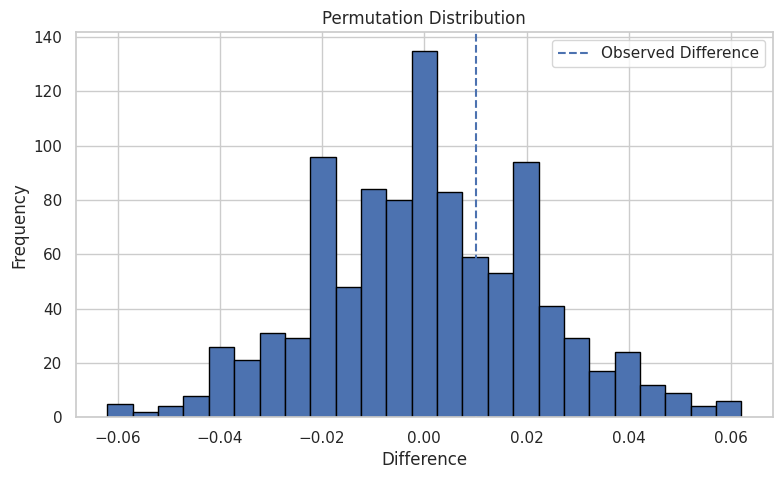

In [6]:
plt.figure(figsize=(9, 5))

plt.hist(
    permutation_diffs,
    bins=25,
    edgecolor="black"
)

plt.axvline(
    observed_diff,
    linestyle="--",
    label="Observed Difference"
)

plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.title("Permutation Distribution")

plt.legend()
plt.show()

### Interpretasi

Observed difference sebesar 0.01 masih berada di dalam rentang
perbedaan yang sering muncul dari hasil pengacakan. Hal ini menunjukkan
bahwa selisih A dan B masih mungkin terjadi karena variasi acak.

## 5. p-value

p-value menunjukkan seberapa besar kemungkinan memperoleh hasil
setidaknya sebesar yang diamati jika hipotesis nol benar.

In [7]:
p_value = np.mean(
    np.abs(permutation_diffs) >= abs(observed_diff)
)

print(f"p-value: {p_value:.4f}")

p-value: 0.7020


### Interpretasi

p-value sebesar 0.7020 lebih besar dari 0.05, sehingga tidak terdapat
bukti yang cukup untuk menyatakan adanya perbedaan signifikan antara
Group A dan Group B.

## 6. t-Test

t-test digunakan untuk membandingkan rata-rata dua kelompok dan
menentukan apakah perbedaannya signifikan secara statistik.

In [13]:
np.random.seed(42)

sample_A = np.random.normal(70, 10, 50)
sample_B = np.random.normal(75, 10, 50)

t_stat, p_val = stats.ttest_ind(
    sample_A,
    sample_B,
    equal_var=False
)

print(f"Mean A : {sample_A.mean():.2f}")
print(f"Mean B : {sample_B.mean():.2f}")
print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_val:.4f}")

Mean A : 67.75
Mean B : 75.18
t-statistic : -4.109
p-value     : 0.0001


### Interpretasi

Mean Group A sebesar 67.75 dan Group B sebesar 75.18.
p-value sebesar 0.0001 menunjukkan bahwa perbedaan rata-rata kedua
kelompok signifikan secara statistik.

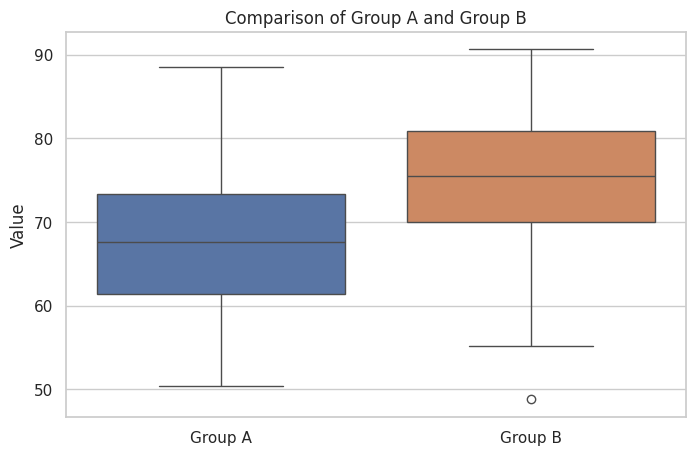

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=[sample_A, sample_B]
)

plt.xticks([0, 1], ["Group A", "Group B"])
plt.ylabel("Value")
plt.title("Comparison of Group A and Group B")

plt.show()

### Interpretasi

Boxplot menunjukkan bahwa nilai Group B cenderung lebih tinggi
dibandingkan Group A. Hal ini terlihat dari posisi median Group B
yang berada di atas Group A.

## 7. ANOVA

ANOVA digunakan untuk membandingkan rata-rata lebih dari dua kelompok
secara bersamaan.

In [10]:
np.random.seed(42)

group_1 = np.random.normal(70, 8, 40)
group_2 = np.random.normal(74, 8, 40)
group_3 = np.random.normal(80, 8, 40)

f_stat, p_anova = stats.f_oneway(
    group_1,
    group_2,
    group_3
)

print(f"F-statistic : {f_stat:.3f}")
print(f"p-value     : {p_anova:.4f}")

F-statistic : 25.449
p-value     : 0.0000


### Interpretasi

Nilai F-statistic sebesar 25.449 dengan p-value 0.0000 menunjukkan
bahwa terdapat perbedaan rata-rata yang signifikan di antara ketiga
kelompok.

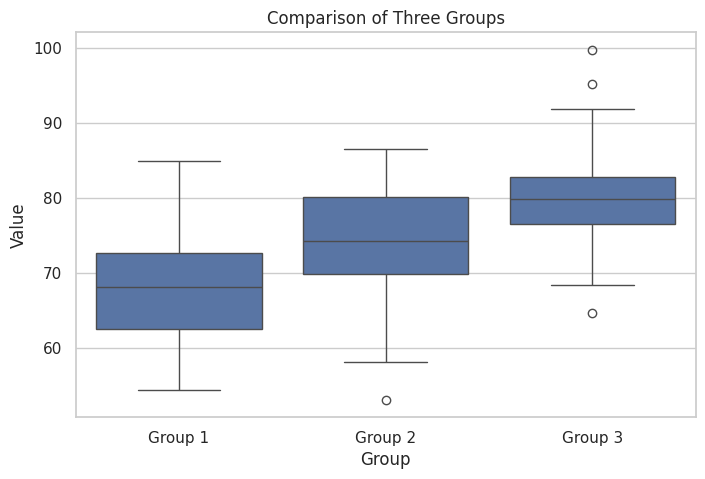

In [11]:
anova_df = pd.DataFrame({
    "Value": np.concatenate([group_1, group_2, group_3]),
    "Group": (
        ["Group 1"] * len(group_1) +
        ["Group 2"] * len(group_2) +
        ["Group 3"] * len(group_3)
    )
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=anova_df,
    x="Group",
    y="Value"
)

plt.title("Comparison of Three Groups")
plt.show()

### Interpretasi

Boxplot menunjukkan perbedaan pusat dan penyebaran dari ketiga kelompok.
Kelompok yang memiliki median lebih tinggi menunjukkan nilai yang
cenderung lebih besar.

## 8. Chi-Square Test

Chi-square test digunakan untuk menguji hubungan antara dua variabel
kategorikal.

In [12]:
observed = np.array([
    [45, 30],
    [25, 50]
])

chi2, p_chi, dof, expected = stats.chi2_contingency(observed)

print(f"Chi-square : {chi2:.3f}")
print(f"p-value    : {p_chi:.4f}")
print(f"Degrees of freedom : {dof}")

Chi-square : 9.670
p-value    : 0.0019
Degrees of freedom : 1


### Interpretasi

Nilai p-value sebesar 0.0019 lebih kecil dari 0.05, sehingga terdapat
hubungan yang signifikan antara dua variabel kategorikal yang diuji.

## 9. Kesimpulan

Statistical experiments digunakan untuk membandingkan kelompok dan
menilai apakah perbedaan yang terlihat cukup kuat secara statistik.

A/B testing digunakan untuk membandingkan dua kelompok, permutation
test membantu melihat variasi acak, t-test membandingkan dua rata-rata,
ANOVA membandingkan lebih dari dua kelompok, sedangkan chi-square
digunakan untuk data kategorikal.

p-value menjadi salah satu ukuran penting untuk membantu mengevaluasi
hasil pengujian hipotesis.

## Referensi

Bruce, P., Bruce, A., & Gedeck, P. (2020).
*Practical Statistics for Data Scientists: 50+ Essential Concepts
Using R and Python*. 2nd Edition. O'Reilly Media.

Repository kode dan dataset:
https://github.com/gedeck/practical-statistics-for-data-scientists